In [1]:
import matplotlib.pyplot as plt
import io
from PIL import Image, ImageChops

white = (255, 255, 255, 255)

def latex_to_img(tex):
    buf = io.BytesIO()
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    plt.axis('off')
    plt.text(0.05, 0.5, f'${tex}$', size=40)
    plt.savefig(buf, format='png')
    plt.close()

    im = Image.open(buf)
    bg = Image.new(im.mode, im.size, white)
    diff = ImageChops.difference(im, bg)
    diff = ImageChops.add(diff, diff, 2.0, -100)
    bbox = diff.getbbox()
    return im.crop(bbox)

In [2]:
from scipy.stats import wilcoxon
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.5f}'.format

def wilcoxon_test(results_best,results_compare):
    pvalue = wilcoxon(x=results_best,y=results_compare).pvalue
    if pvalue<=0.001:
        return {}
    elif pvalue>0.001 and pvalue<0.05:
        return {'dag':'--rwrap'}
    else:
        return {'ddag':'--rwrap'}

Error in sys.excepthook:
Traceback (most recent call last):
  File "/home/pgonzalez/miniconda3/envs/histnet/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 1934, in showtraceback
    stb = value._render_traceback_()
AttributeError: 'RuntimeError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/pgonzalez/miniconda3/envs/histnet/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 1936, in showtraceback
    stb = self.InteractiveTB.structured_traceback(etype,
  File "/home/pgonzalez/miniconda3/envs/histnet/lib/python3.9/site-packages/IPython/core/ultratb.py", line 1105, in structured_traceback
    return FormattedTB.structured_traceback(
  File "/home/pgonzalez/miniconda3/envs/histnet/lib/python3.9/site-packages/IPython/core/ultratb.py", line 999, in structured_traceback
    return VerboseTB.structured_traceback(
  File "/home/pgonzalez/mi

In [3]:
import pandas as pd
import os

export_dir = 'latex'
path = "results"

def show_results_table(experiment_names, base_path='', include_std=False, row_names=None, error_measures=['RAE']):
    table = pd.DataFrame(columns=error_measures, dtype='float')
    results_error = {em: {} for em in error_measures}

    available_experiments = []

    for experiment in experiment_names:
        path_errors = os.path.join(base_path, path, experiment + '_errors.txt')
        if os.path.exists(path_errors):
            try:
                results = pd.read_csv(path_errors)
                available_experiments.append(experiment)
                for error_measure in error_measures:
                    if error_measure in results:
                        results_error[error_measure][experiment] = results[error_measure]
                        table.loc[experiment, error_measure] = results[error_measure].mean()
            except Exception as e:
                print(f"Could not read {path_errors}: {e}")
        else:
            print(f"File {path_errors} does not exist.")

    if table.empty:
        return "No results available yet.", results_error

    best_method = {}
    for error_measure in error_measures:
        if table[error_measure].notna().any():
            best_method[error_measure] = table[error_measure].idxmin()

    table_style = table.style

    # Apply Wilcoxon test (if available)
    for experiment in available_experiments:
        for error_measure in error_measures:
            if experiment != best_method.get(error_measure) and experiment in results_error[error_measure]:
                try:
                    # Ensure both experiment and best method have results
                    base_results = results_error[error_measure].get(best_method[error_measure])
                    if base_results is not None:
                        table_style = table_style.set_properties(
                            subset=pd.IndexSlice[experiment, error_measure],
                            **wilcoxon_test(results_error[error_measure][experiment], base_results)
                        )
                except Exception as e:
                    print(f"Wilcoxon test failed for {experiment} vs {best_method[error_measure]}: {e}")

    for error_measure in error_measures:
        if error_measure in table.columns:
            table_style = table_style.highlight_min(axis=0, props='textbf:--rwrap;', subset=error_measure)

    def add_deviation(x, std):
        return "{:.5f}".format(x) + ' $\pm$ ' + "{:.5f}".format(std)

    if include_std:
        for experiment in available_experiments:
            for error_measure in error_measures:
                if experiment in results_error[error_measure]:
                    std_value = results_error[error_measure][experiment].std()
                    table_style = table_style.format(
                        formatter=lambda x, std=std_value: add_deviation(x, std),
                        subset=pd.IndexSlice[experiment, error_measure]
                    )

    latex_code = table_style.to_latex(hrules=True, column_format="r|" + "r" * len(table.columns))
    if row_names is not None:
        for experiment_name, row_name in zip(experiment_names, row_names):
            latex_code = latex_code.replace(experiment_name, row_name)

    return latex_code.replace("_", "\\_"), results_error


## Results CIFAR 10

In [4]:
experiment_names = ["cifar10_CC_mrae","cifar10_PCC_mrae","cifar10_ACC_mrae","cifar10_PACC_mrae","cifar10_DMy_mrae","cifar10_EMQ_mrae","cifar10_EMQ-Platt_mrae","cifar10_deepsets_median_final","cifar10_deepsets_max_final","cifar10_deepsets_avg_final","cifar10_histnet_final","cifar10_gmnet_final","cifar10_gmnet_01_final","cifar10_gmnet_001_final","cifar10_gmnet_0001_final"]
row_names = ["CC","PCC","ACC","PACC","DMy","EMQ","EMQ-Platt","DeepSets (Median)","DeepSets (Max)","DeepSets (Avg)","HistNetQ","GMNet","GMNet (reg 0.1)","GMNet (reg 0.01)","GMNet (reg 0.001)"]
table,_ = show_results_table(experiment_names=experiment_names, base_path='', include_std=True,error_measures=['RAE'], row_names=row_names)
print(table)
with open(os.path.join(export_dir,'tables/cifar10.tex'),'w') as f:
    f.write(table)

\begin{tabular}{r|r}
\toprule
 & RAE \\
\midrule
CC & 0.52963 $\pm$ 0.69583 \\
PCC & 0.60844 $\pm$ 0.74459 \\
ACC & 0.36017 $\pm$ 0.47573 \\
PACC & 0.35578 $\pm$ 0.41790 \\
DMy & 0.21438 $\pm$ 0.23418 \\
EMQ & \ddag{0.18864 $\pm$ 0.20515} \\
EMQ-Platt & 0.50291 $\pm$ 0.59707 \\
DeepSets (Median) & 0.22072 $\pm$ 0.23906 \\
DeepSets (Max) & 0.93907 $\pm$ 0.64273 \\
DeepSets (Avg) & 0.22114 $\pm$ 0.22161 \\
HistNetQ & 0.22712 $\pm$ 0.24774 \\
GMNet & \ddag{0.17275 $\pm$ 0.14382} \\
GMNet (reg 0.1) & 0.18189 $\pm$ 0.14567 \\
GMNet (reg 0.01) & \textbf{0.16840 $\pm$ 0.12279} \\
GMNet (reg 0.001) & \ddag{0.17233 $\pm$ 0.14956} \\
\bottomrule
\end{tabular}



In [5]:
experiment_names = ["cifar100coarse_CC_mrae","cifar100coarse_PCC_mrae","cifar100coarse_ACC_mrae","cifar100coarse_PACC_mrae","cifar100coarse_DMy_mrae","cifar100coarse_EMQ_mrae","cifar100coarse_EMQ-Platt_mrae","cifar100coarse_deepsets_median_final","cifar100coarse_deepsets_max_final","cifar100coarse_deepsets_avg_final","cifar100coarse_histnet_final","cifar100coarse_gmnet_final","cifar100coarse_gmnet_01_final","cifar100coarse_gmnet_001_final","cifar100coarse_gmnet_0001_final"]
row_names = ["CC","PCC","ACC","PACC","DMy","EMQ","EMQ-Platt","DeepSets (Median)","DeepSets (Max)","DeepSets (Avg)","HistNetQ","GMNet","GMNet (reg 0.1)","GMNet (reg 0.01)","GMNet (reg 0.001)"]
table,_ = show_results_table(experiment_names=experiment_names, base_path='', include_std=True,error_measures=['RAE'], row_names=row_names)
print(table)
with open(os.path.join(export_dir,'tables/cifar100coarse.tex'),'w') as f:
    f.write(table)

\begin{tabular}{r|r}
\toprule
 & RAE \\
\midrule
CC & 0.89765 $\pm$ 0.58096 \\
PCC & 0.95819 $\pm$ 0.60285 \\
ACC & 0.80224 $\pm$ 0.52771 \\
PACC & 0.79591 $\pm$ 0.50565 \\
DMy & 0.48927 $\pm$ 0.31433 \\
EMQ & 0.48886 $\pm$ 0.31508 \\
EMQ-Platt & 0.57867 $\pm$ 0.24804 \\
DeepSets (Median) & 0.66561 $\pm$ 0.44376 \\
DeepSets (Max) & 0.72702 $\pm$ 0.37666 \\
DeepSets (Avg) & 0.56297 $\pm$ 0.36657 \\
HistNetQ & 0.68841 $\pm$ 0.41942 \\
GMNet & \textbf{0.38838 $\pm$ 0.23310} \\
GMNet (reg 0.1) & 0.40523 $\pm$ 0.24273 \\
GMNet (reg 0.01) & 0.41208 $\pm$ 0.24299 \\
GMNet (reg 0.001) & \ddag{0.38983 $\pm$ 0.22428} \\
\bottomrule
\end{tabular}



In [6]:
# Build a pivot table with L as rows and K as columns (mean \u00b1 std of RAE)
import numpy as np
import pandas as pd
import os

# Provided parameter grids
K_list = [10, 50, 100, 150, 200]
L_list = [1, 3, 6, 9, 12]

records = []
for L in L_list:
    for K in K_list:
        exp = f"cifar10_gmnet_layers{L}_gaussians{K}"
        path_errors = os.path.join(path, exp + '_errors.txt')
        mean = float('nan')
        std = float('nan')
        if os.path.exists(path_errors):
            try:
                res = pd.read_csv(path_errors)
                if 'RAE' in res.columns:
                    mean = res['RAE'].mean()
                    std = res['RAE'].std()
            except Exception as e:
                print(f"Could not read {path_errors}: {e}")
        records.append({'L': L, 'K': K, 'mean': mean, 'std': std})

df = pd.DataFrame(records)

def fmt_mean_std(m, s):
    if np.isfinite(m):
        return f"{m:.5f} $\\\\pm$ {s:.5f}"
    return '-'

# Build table with L rows and K columns
table = pd.DataFrame(index=L_list, columns=K_list)
for _, row in df.iterrows():
    table.at[int(row['L']), int(row['K'])] = fmt_mean_std(row['mean'], row['std'])

print(table)

os.makedirs(os.path.join(export_dir, 'tables'), exist_ok=True)
latex = table.to_latex(na_rep='-', escape=False)
with open(os.path.join(export_dir, 'tables/cifar10_grid.tex'), 'w') as f:
    f.write(latex)


                       10                      50                      100                     150                     200
1   0.24604 $\\pm$ 0.25845  0.18907 $\\pm$ 0.15924  0.19082 $\\pm$ 0.16723  0.18704 $\\pm$ 0.18150  0.17944 $\\pm$ 0.16904
3   0.17291 $\\pm$ 0.15232  0.16429 $\\pm$ 0.12418  0.17052 $\\pm$ 0.15674  0.16642 $\\pm$ 0.11012  0.16912 $\\pm$ 0.14393
6   0.16741 $\\pm$ 0.13046  0.20830 $\\pm$ 0.09502  0.16648 $\\pm$ 0.12689  0.17519 $\\pm$ 0.11419  0.22696 $\\pm$ 0.14192
9   0.16829 $\\pm$ 0.13388  0.17259 $\\pm$ 0.15015  0.16840 $\\pm$ 0.12279  0.17483 $\\pm$ 0.12120  0.16702 $\\pm$ 0.11565
12  0.17655 $\\pm$ 0.12912  0.17676 $\\pm$ 0.15899  0.17091 $\\pm$ 0.13073  0.17707 $\\pm$ 0.14390  0.17784 $\\pm$ 0.14426


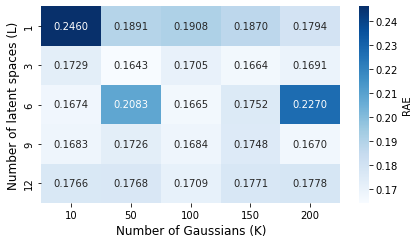

Figure saved to:
  - latex/figures/cifar10_gmnet_grid.png
  - latex/figures/cifar10_gmnet_grid.pdf


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a matrix of mean values for the heatmap
mean_matrix = np.zeros((len(L_list), len(K_list)))
for i, L in enumerate(L_list):
    for j, K in enumerate(K_list):
        row = df[(df['L'] == L) & (df['K'] == K)]
        if not row.empty:
            mean_matrix[i, j] = row.iloc[0]['mean']
        else:
            mean_matrix[i, j] = np.nan

# Create figure
fig, ax = plt.subplots(figsize=(6, 3.5))

# Create heatmap
im = sns.heatmap(mean_matrix, 
                  xticklabels=K_list, 
                  yticklabels=L_list,
                  cmap='Blues',  # reversed so lower RAE (better) is darker
                  annot=True, 
                  fmt='.4f',
                  cbar_kws={'label': 'RAE'},
                  ax=ax)

ax.set_xlabel('Number of Gaussians (K)', fontsize=12)
ax.set_ylabel('Number of latent spaces (L)', fontsize=12)
#ax.set_title('$K$ and $L$ hyperparameter exploration', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(export_dir, 'figures/cifar10_gmnet_grid.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(export_dir, 'figures/cifar10_gmnet_grid.pdf'), bbox_inches='tight')
plt.show()

print("Figure saved to:")
print(f"  - {os.path.join(export_dir, 'figures/cifar10_gmnet_grid.png')}")
print(f"  - {os.path.join(export_dir, 'figures/cifar10_gmnet_grid.pdf')}")


In [8]:
import wandb

# Initialize wandb API
api = wandb.Api()

# Query your project - replace with your actual project name
project = "pglez82/cifar10"  # e.g., "pgonzalez/gmnet"
runs = api.runs(project)
# Extract training times for GMNet grid search experiments
training_times = {}
for run in runs:
    # Check if it's a GMNet grid search experiment
    if "cifar10_gmnet_layers" in run.name:
        # Parse L and K from run name
        parts = run.name.split("_")
        L = int(parts[2].replace("layers", ""))
        K = int(parts[3].replace("gaussians", ""))
        # Get training time from run summary or config
        if "_runtime" in run.summary:
            # wandb stores runtime in seconds
            training_times[(L, K)] = run.summary["_runtime"]/run.summary["_step"]  # convert to minutes

print(f"Found {len(training_times)} runs with training time data")
print(training_times)


Found 25 runs with training time data
{(12, 200): 48.99468576367045, (12, 150): 38.42238842297304, (12, 50): 26.484239072435432, (12, 10): 14.761849613750682, (12, 100): 37.144063498165565, (6, 200): 26.371321543036103, (6, 150): 21.455627734563787, (6, 50): 12.721067558436973, (6, 10): 10.18985299972583, (6, 100): 18.16845266120022, (3, 200): 16.029314821588976, (3, 150): 13.661538910674283, (3, 50): 10.53673318857272, (3, 10): 9.715566192746467, (3, 100): 12.107022889815815, (9, 200): 37.62402094050151, (9, 150): 29.867586839828768, (9, 50): 21.56551326025016, (9, 10): 12.13183861399002, (9, 100): 29.729183271765983, (1, 200): 10.81491404831529, (1, 150): 10.264520933827056, (1, 100): 10.17974980251462, (1, 50): 10.19821350305065, (1, 10): 10.097361022813452}


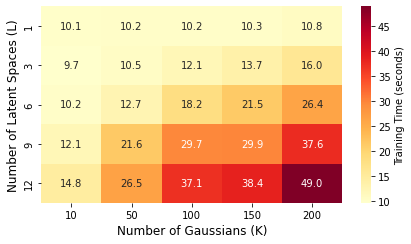

Training time figure saved to:
  - latex/figures/cifar10_gmnet_training_time.png
  - latex/figures/cifar10_gmnet_training_time.pdf


In [9]:
# Create a matrix of training times for the heatmap
time_matrix = np.zeros((len(L_list), len(K_list)))
for i, L in enumerate(L_list):
    for j, K in enumerate(K_list):
        if (L, K) in training_times:
            time_matrix[i, j] = training_times[(L, K)]
        else:
            time_matrix[i, j] = np.nan

# Create figure
fig, ax = plt.subplots(figsize=(6, 3.5))

# Create heatmap
im = sns.heatmap(time_matrix, 
                  xticklabels=K_list, 
                  yticklabels=L_list,
                  cmap='YlOrRd',  # Darker red = longer training time
                  annot=True, 
                  fmt='.1f',
                  cbar_kws={'label': 'Training Time (seconds)'},
                  ax=ax)

ax.set_xlabel('Number of Gaussians (K)', fontsize=12)
ax.set_ylabel('Number of Latent Spaces (L)', fontsize=12)
#ax.set_title('Training Time (seconds/epoch)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(export_dir, 'figures/cifar10_gmnet_training_time.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(export_dir, 'figures/cifar10_gmnet_training_time.pdf'), bbox_inches='tight')
plt.show()

print("Training time figure saved to:")
print(f"  - {os.path.join(export_dir, 'figures/cifar10_gmnet_training_time.png')}")
print(f"  - {os.path.join(export_dir, 'figures/cifar10_gmnet_training_time.pdf')}")


In [10]:
import wandb

# Initialize wandb API
api = wandb.Api()

experiment_names = ['cifar10_gmnet_final', 'cifar10_gmnet_01_final', 'cifar10_gmnet_001_final', 'cifar10_gmnet_0001_final']

# Query your project - replace with your actual project name
project = "pglez82/cifar10"  # e.g., "pgonzalez/gmnet"
runs = api.runs(project)
training_times = {}
for run in runs:
    if run.name in experiment_names:
        # Parse L and K from run name
        # Get training time from run summary or config
        print(f"Run name: {run.name}")
        if "_runtime" in run.summary:
            # wandb stores runtime in seconds
            print(run.summary["_runtime"]/run.summary["_step"])  # convert to minutes



Run name: cifar10_gmnet_0001_final
23.98518589677482
Run name: cifar10_gmnet_01_final
24.177070840105735
Run name: cifar10_gmnet_001_final
24.270458061034947
Run name: cifar10_gmnet_final
23.2504585170355
